In [1]:
import pandas as pd

df = pd.read_parquet("./processed/purchases.parquet")

df.head()

,league,summer,window,direction,club_id,club_name,player_id,player_name,age,nationality,...,origin_country_uefa,origin_uefa_rank,origin_uefa_5y,fee_index,fee_adjusted,no_minutes_before,model_exclusion,in_price_model,in_ranking,in_phase5
0,ENG,2019,summer,in,989,AFC Bournemouth,320411,Philip Billing,23,Denmark,...,England,2,85.462,0.618056,2.669663e+07,False,NaN,True,False,False
1,ENG,2019,summer,in,11,Arsenal FC,46741,David Luiz,32,Brazil,...,England,2,85.462,0.618056,1.407640e+07,False,NaN,True,False,False
2,ENG,2019,summer,in,11,Arsenal FC,343052,Nicolas Pépé,24,Cote d'Ivoire,...,France,5,58.498,0.618056,1.294382e+08,False,NaN,True,False,False
3,ENG,2019,summer,in,11,Arsenal FC,495666,William Saliba,18,France,...,France,5,58.498,0.618056,4.853933e+07,False,NaN,True,False,False
4,ENG,2019,summer,in,405,Aston Villa,183720,Anwar El Ghazi,24,Netherlands,...,France,5,58.498,0.618056,1.456180e+07,True,no_league_minutes_before,False,False,False


In [7]:
print(df['summer'].min())
print(df['summer'].max())
print(df['summer'].unique())
print(df['window'].unique())
print(df.info)

2019
2026
[2019 2020 2021 2022 2023 2024 2025 2026]
<ArrowStringArray>
['summer']
Length: 1, dtype: str
<bound method DataFrame.info of      league  summer  window direction  club_id        club_name  player_id  \
0       ENG    2019  summer        in      989  AFC Bournemouth     320411   
1       ENG    2019  summer        in       11       Arsenal FC      46741   
2       ENG    2019  summer        in       11       Arsenal FC     343052   
3       ENG    2019  summer        in       11       Arsenal FC     495666   
4       ENG    2019  summer        in      405      Aston Villa     183720   
...     ...     ...     ...       ...      ...              ...        ...   
1705    ITA    2026  summer        in      410   Udinese Calcio     336125   
1706    ITA    2026  summer        in      410   Udinese Calcio     834752   
1707    ITA    2026  summer        in      607       Venezia FC     607034   
1708    ITA    2026  summer        in      607       Venezia FC     467563   
1709  

In [58]:
from matplotlib.ticker import MultipleLocator
import matplotlib.pyplot as plt

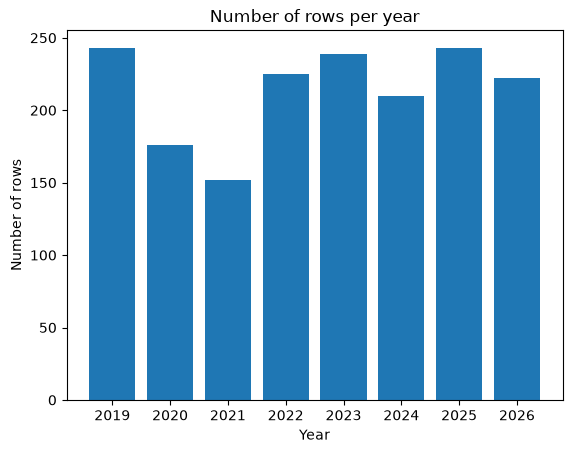

In [14]:
dfs_by_year = {
    year: group.copy()
    for year, group in df.groupby("summer")
}

counts = {year: len(yearly_df) for year, yearly_df in dfs_by_year.items()}

plt.bar(counts.keys(), counts.values())
plt.xlabel("Year")
plt.ylabel("Number of rows")
plt.title("Number of rows per year")
plt.show()

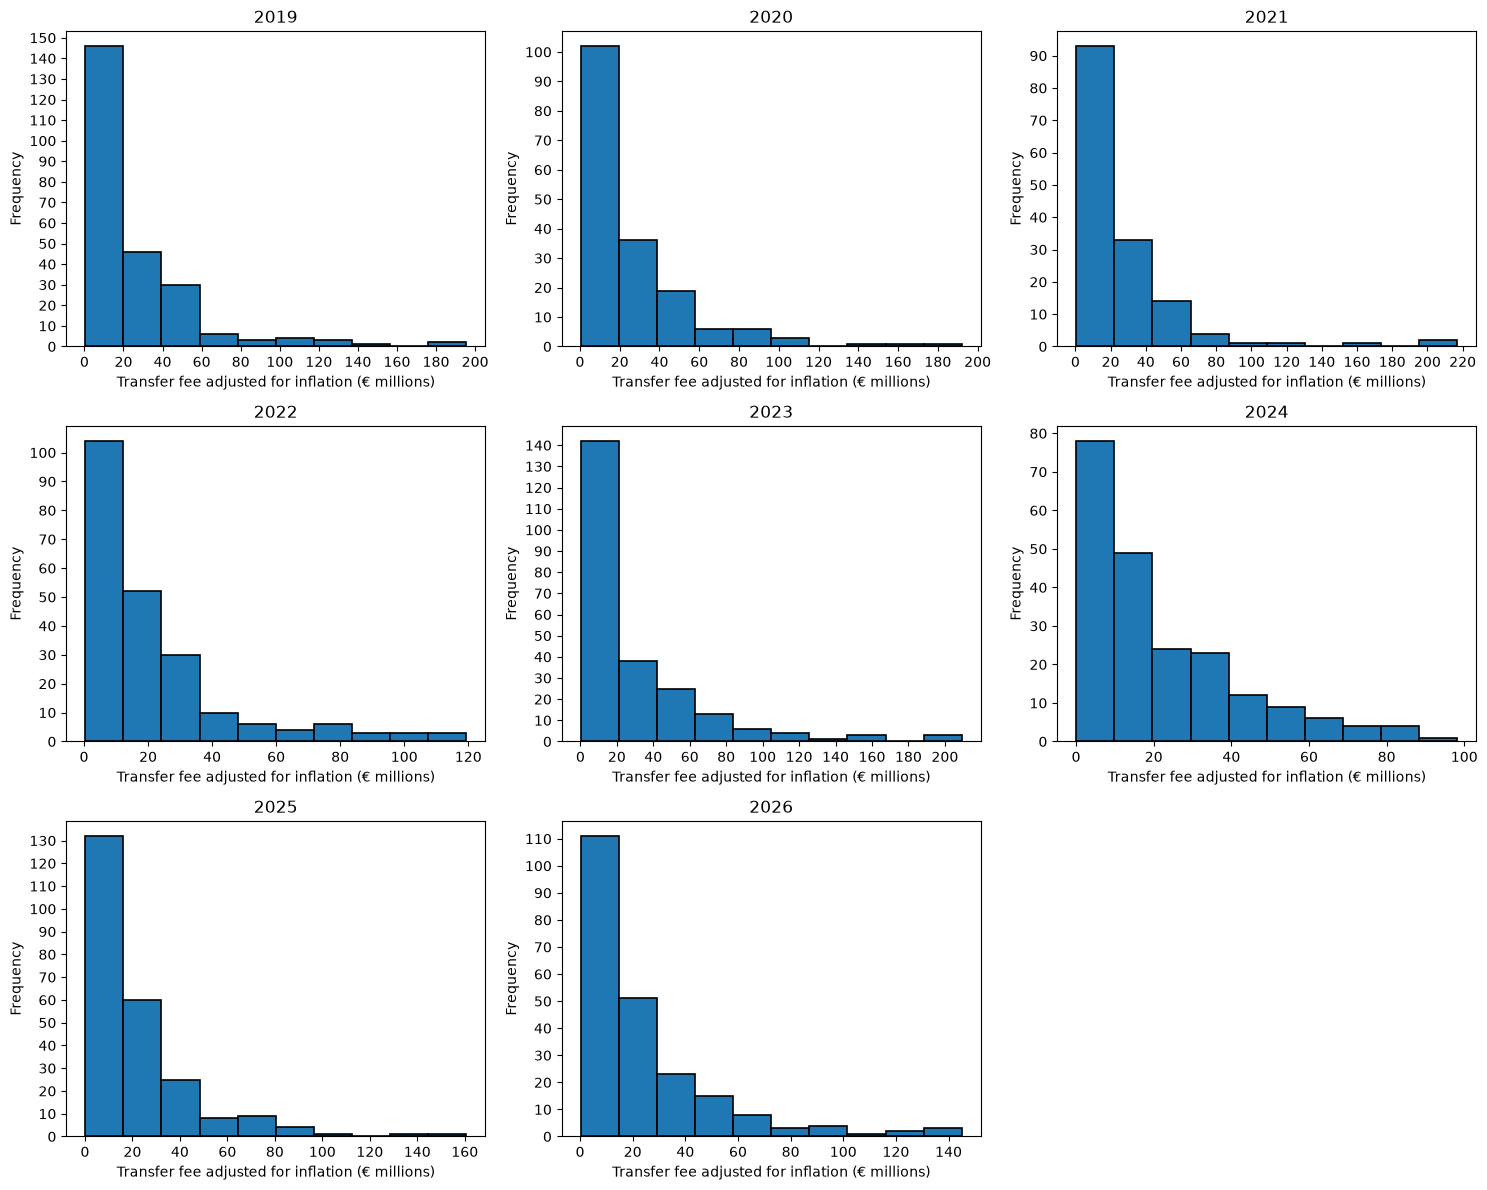

In [63]:
from matplotlib.ticker import MultipleLocator
import matplotlib.pyplot as plt

n = len(dfs_by_year)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(15, 4 * nrows)
)

axes = axes.flatten()

for ax, (year, df) in zip(axes, dfs_by_year.items()):
    (df["fee_adjusted"] / 1_000_000).plot.hist(
        ax=ax,
        edgecolor="black",
        linewidth=1.2,
        grid=False
    )

    ax.set_title(str(year))
    ax.set_xlabel("Transfer fee adjusted for inflation (€ millions)")
    ax.set_ylabel("Frequency")

    # X-axis: jumps of 20 million
    ax.xaxis.set_major_locator(MultipleLocator(20))

    # Y-axis: jumps of 10
    ax.yaxis.set_major_locator(MultipleLocator(10))

# Hide unused subplots
for ax in axes[len(dfs_by_year):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

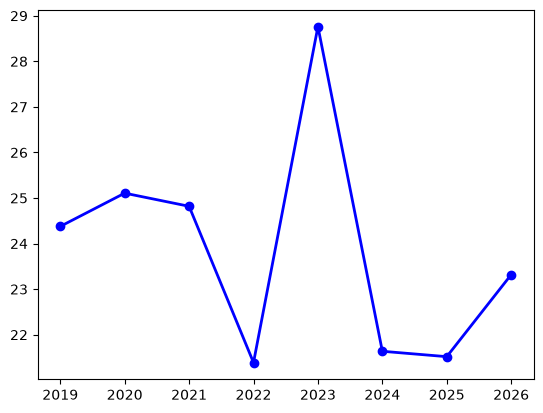

In [68]:
years = [
    year
    for year in dfs_by_year.keys()
    if year >= 2019
]

means = [
    dfs_by_year[year]['fee_adjusted'].mean() / 1_000_000
    for year in dfs_by_year
    if year >= 2019
]

plt.plot(years, means, marker='o', linestyle='-', color='b', linewidth=2)
plt.show()